In [1]:
import atoti as tt
import psycopg2
import pandas as pd
import os
from dotenv import load_dotenv
from pathlib import Path

load_dotenv(Path(".env"), override=True)

session = tt.Session.start()
print("Atoti session started!")

Welcome to Atoti 0.9.15!

By using this community edition, you agree with the license available at https://docs.activeviam.com/products/atoti/python-sdk/latest/eula.html.
Browse the official documentation at https://docs.activeviam.com/products/atoti/python-sdk.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.
Atoti session started!


In [2]:
print(dir(tt))

['ADVANCED_APP_EXTENSION', 'AggregateCache', 'AggregateProvider', 'AiConfig', 'Authenticate', 'AutoMultiColumnArrayConversion', 'BOOLEAN', 'BasicAuthentication', 'BasicAuthenticationConfig', 'BrandingConfig', 'Client', 'ClientCertificate', 'ClientCertificateConfig', 'ClientSideEncryptionConfig', 'Cluster', 'ClusterDefinition', 'Column', 'CorsConfig', 'CsvLoad', 'Cube', 'CumulativeScope', 'CustomOrder', 'DOUBLE', 'DOUBLE_ARRAY', 'DataType', 'DiscoveryProtocol', 'ExternalAggregateTable', 'ExternalColumn', 'ExternalDatabaseConnection', 'ExternalTable', 'ExternalTables', 'FLOAT', 'FLOAT_ARRAY', 'Hierarchy', 'HttpsConfig', 'I18nConfig', 'INT', 'INT_ARRAY', 'JwtConfig', 'KerberosConfig', 'KeyPair', 'LOCAL_DATE', 'LOCAL_DATE_TIME', 'LOCAL_TIME', 'LONG', 'LONG_ARRAY', 'LdapConfig', 'Level', 'LoggingConfig', 'LoginConfig', 'MdxQueryResult', 'Measure', 'MultiColumnArrayConversion', 'MultiRowArrayConversion', 'NaturalOrder', 'OAuth2ResourceOwnerPasswordAuthentication', 'OBJECT', 'OidcConfig', 'Or

## Load Data Dari Supabase ke Atoti

In [3]:
db_url = os.getenv("DATABASE_URL")

# Load materialized view sebagai tabel Atoti
df_harga = pd.read_sql("SELECT * FROM mv_harga_bulanan", 
                        psycopg2.connect(db_url))
df_indikator = pd.read_sql("SELECT * FROM mv_indikator_tahunan", 
                            psycopg2.connect(db_url))

print(f"mv_harga_bulanan: {len(df_harga)} baris")
print(f"mv_indikator_tahunan: {len(df_indikator)} baris")
print(df_harga.head())

C:\Users\RASYA\AppData\Local\Temp\ipykernel_18052\3783077495.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_harga = pd.read_sql("SELECT * FROM mv_harga_bulanan",
C:\Users\RASYA\AppData\Local\Temp\ipykernel_18052\3783077495.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_indikator = pd.read_sql("SELECT * FROM mv_indikator_tahunan",


mv_harga_bulanan: 3834 baris
mv_indikator_tahunan: 12 baris
   year  month  quarter country_name region           commodity_name  \
0  2024      2        1          PHL  ASEAN                 Squashes   
1  2025      5        2          KHM  ASEAN  Sweet potatoes (orange)   
2  2025     12        4          TLS  ASEAN         Tomatoes (local)   
3  2025      1        1          PHL  ASEAN     Beans (green, fresh)   
4  2024     10        4          PHL  ASEAN       Rice (well milled)   

                category  rata_harga  min_harga  max_harga  total_observasi  
0  vegetables and fruits     42.0180      13.18      70.00               65  
1     cereals and tubers   2088.5625    1200.00    3000.00               16  
2  vegetables and fruits      2.1383       1.07       3.29                6  
3  vegetables and fruits    136.9956      85.71     220.00               34  
4     cereals and tubers     54.5277      49.65      63.13               81  


## Buat DataMart & Cube

In [4]:
# Buat table Atoti dari dataframe
tbl_harga = session.read_pandas(
    df_harga,
    table_name="Harga Pangan",
    keys=["year", "month", "country_name", "commodity_name"]
)

tbl_indikator = session.read_pandas(
    df_indikator,
    table_name="Indikator Ekonomi",
    keys=["year", "country_name"]
)

# Buat cube
cube = session.create_cube(tbl_harga, "Analisis Harga Pangan ASEAN")

print("Cube berhasil dibuat!")
print(cube.measures)

Cube berhasil dibuat!
{'contributors.COUNT': <atoti.measure.Measure object at 0x0000026544B20040>, 'max_harga.MEAN': <atoti.measure.Measure object at 0x0000026544B21C30>, 'max_harga.SUM': <atoti.measure.Measure object at 0x000002654565FC70>, 'min_harga.MEAN': <atoti.measure.Measure object at 0x000002654565F1C0>, 'min_harga.SUM': <atoti.measure.Measure object at 0x000002654565FA00>, 'quarter.MEAN': <atoti.measure.Measure object at 0x000002654565DF60>, 'quarter.SUM': <atoti.measure.Measure object at 0x000002654565F4C0>, 'rata_harga.MEAN': <atoti.measure.Measure object at 0x000002654565E440>, 'rata_harga.SUM': <atoti.measure.Measure object at 0x000002654565EFB0>, 'total_observasi.MEAN': <atoti.measure.Measure object at 0x000002654565CC10>, 'total_observasi.SUM': <atoti.measure.Measure object at 0x000002654565D720>, 'update.TIMESTAMP': <atoti.measure.Measure object at 0x000002654565E4A0>}


In [11]:
print(cube.levels)

{('Harga Pangan', 'year', 'year'): <atoti.level.Level object at 0x00000265458CF3D0>, ('Harga Pangan', 'region', 'region'): <atoti.level.Level object at 0x00000265458CC520>, ('Harga Pangan', 'country_name', 'country_name'): <atoti.level.Level object at 0x00000265458CC5E0>, ('Harga Pangan', 'month', 'month'): <atoti.level.Level object at 0x00000265458CC2E0>, ('Harga Pangan', 'commodity_name', 'commodity_name'): <atoti.level.Level object at 0x00000265458CC130>, ('Harga Pangan', 'category', 'category'): <atoti.level.Level object at 0x00000265458CC100>}


## Custom Measures

In [5]:
m = cube.measures
h = cube.hierarchies

# Measure custom
m["Rata-rata Harga"] = tt.agg.mean(tbl_harga["rata_harga"])
m["Harga Tertinggi"] = tt.agg.max(tbl_harga["max_harga"])
m["Harga Terendah"] = tt.agg.min(tbl_harga["min_harga"])
m["Total Observasi"] = tt.agg.sum(tbl_harga["total_observasi"])

print("Custom measures berhasil dibuat!")
print([k for k in m.keys()])

Custom measures berhasil dibuat!
['Harga Terendah', 'Harga Tertinggi', 'Rata-rata Harga', 'Total Observasi', 'contributors.COUNT', 'max_harga.MEAN', 'max_harga.SUM', 'min_harga.MEAN', 'min_harga.SUM', 'quarter.MEAN', 'quarter.SUM', 'rata_harga.MEAN', 'rata_harga.SUM', 'total_observasi.MEAN', 'total_observasi.SUM', 'update.TIMESTAMP']


## Widget Visualisasi

In [7]:
# Tampilkan URL dashboard Atoti
print(f"Atoti UI: {session.url}")

# Widget 1: Rata-rata harga per negara
widget1 = cube.query(
    m["Rata-rata Harga"],
    levels=[cube.levels["country_name"], cube.levels["year"]]
)

print(widget1)

Atoti UI: http://localhost:60235
                  Rata-rata Harga
country_name year                
IDN          2024       41,837.86
             2025       43,380.77
KHM          2024        5,816.58
             2025        5,889.53
LAO          2024       48,209.29
             2025       49,665.50
MMR          2024        4,845.73
             2025        4,727.55
PHL          2024          143.29
             2025          150.97
TLS          2024            1.83
             2025            1.70


## OLAP

### Rata-rata harga per negara per tahun

In [8]:
q1 = cube.query(
    m["Rata-rata Harga"],
    m["Harga Tertinggi"],
    m["Harga Terendah"],
    levels=[cube.levels["country_name"], cube.levels["year"]]
)
print("=== Harga per Negara per Tahun ===")
print(q1)

=== Harga per Negara per Tahun ===
                  Rata-rata Harga Harga Tertinggi Harga Terendah
country_name year                                               
IDN          2024       41,837.86      300,000.00       7,150.00
             2025       43,380.77      247,500.00      11,500.00
KHM          2024        5,816.58       35,000.00         300.00
             2025        5,889.53       90,000.00         300.00
LAO          2024       48,209.29      150,000.00       1,683.33
             2025       49,665.50      256,000.00       1,833.00
MMR          2024        4,845.73       27,540.00         245.00
             2025        4,727.55       45,000.00         300.00
PHL          2024          143.29        1,130.00           6.81
             2025          150.97        1,216.67           7.30
TLS          2024            1.83           12.99            .14
             2025            1.70            9.81            .15


### Rata-rata harga per kategori

In [9]:
q2 = cube.query(
    m["Rata-rata Harga"],
    m["Total Observasi"],
    levels=[cube.levels["category"], cube.levels["year"]]
)
print("\n=== Harga per Kategori ===")
print(q2)


=== Harga per Kategori ===
                           Rata-rata Harga Total Observasi
category              year                                
cereals and tubers    2024        4,791.33          11,107
                      2025        4,462.13           9,745
meat, fish and eggs   2024       26,642.63          24,812
                      2025       25,831.67          22,855
milk and dairy        2024        1,800.88             337
                      2025        1,761.88             164
miscellaneous food    2024        7,777.81           5,538
                      2025        7,086.49           4,224
non-food              2024       11,651.96             342
                      2025       11,119.69             361
oil and fats          2024       21,619.72           4,180
                      2025       23,012.45           3,653
pulses and nuts       2024        3,427.82           3,489
                      2025        3,173.91           2,522
vegetables and fruits 2024  

### Rata-rata harga per bulan

In [12]:
q3 = cube.query(
    m["Rata-rata Harga"],
    levels=[cube.levels["country_name"], cube.levels["month"]]
)
print("\n=== Harga per Bulan ===")
print(q3)


=== Harga per Bulan ===
                   Rata-rata Harga
country_name month                
IDN          1           44,255.74
             2           41,547.54
             3           41,522.17
             4           42,245.30
             5           42,068.13
...                            ...
TLS          8                1.74
             9                1.73
             10               1.69
             11               1.69
             12               1.78

[72 rows x 1 columns]


## Visualisasi hasil OLAP

### Rata rata harga per tahun

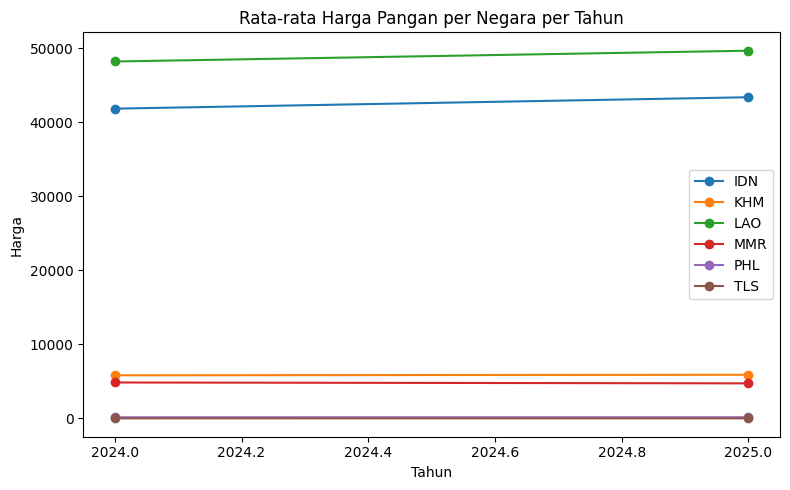

In [14]:
import matplotlib.pyplot as plt

q1_reset = q1.reset_index()
fig, ax = plt.subplots(figsize=(8, 5))

for country, group in q1_reset.groupby("country_name"):
    ax.plot(group["year"], group["Rata-rata Harga"], marker='o', label=country)

ax.set_title("Rata-rata Harga Pangan per Negara per Tahun")
ax.set_xlabel("Tahun")
ax.set_ylabel("Harga")
ax.legend()
plt.tight_layout()
plt.savefig("viz_harga_negara.png", dpi=150)
plt.show()

### Rata rata harga per kategori

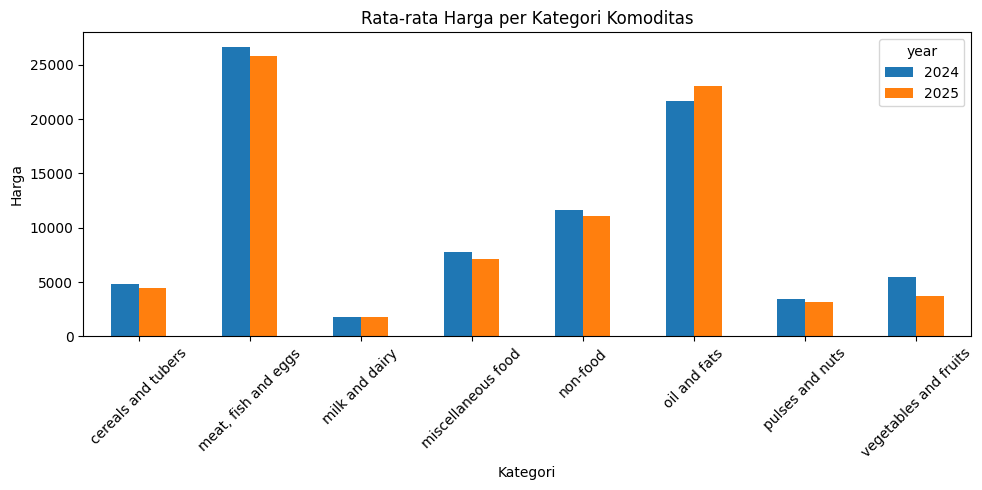

In [15]:
q2_reset = q2.reset_index()
q2_pivot = q2_reset.pivot(index="category", columns="year", values="Rata-rata Harga")

fig, ax = plt.subplots(figsize=(10, 5))
q2_pivot.plot(kind="bar", ax=ax)
ax.set_title("Rata-rata Harga per Kategori Komoditas")
ax.set_xlabel("Kategori")
ax.set_ylabel("Harga")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("viz_harga_kategori.png", dpi=150)
plt.show()

### Rata rata harga per bulan

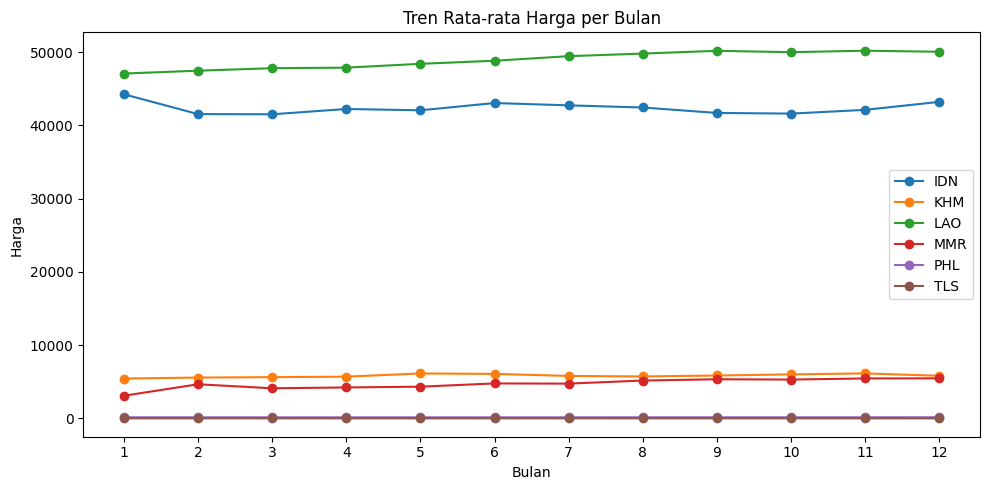

In [16]:
q3_reset = q3.reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for country, group in q3_reset.groupby("country_name"):
    ax.plot(group["month"], group["Rata-rata Harga"], marker='o', label=country)

ax.set_title("Tren Rata-rata Harga per Bulan")
ax.set_xlabel("Bulan")
ax.set_ylabel("Harga")
ax.set_xticks(range(1, 13))
ax.legend()
plt.tight_layout()
plt.savefig("viz_harga_bulan.png", dpi=150)
plt.show()

In [18]:
session.close()